In [1]:
# ============================================
# NOTEBOOK 5: PLAYER xG ANALYSIS
# Who overperformed their xG?
# Who underperformed?
# Which players took the best quality shots?
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mplsoccer import Pitch
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load feature matrix
shots = pd.read_csv('../data/shots_features.csv')

print("Libraries loaded")
print(f"Shots: {len(shots)}")
print(f"\nPlayers in dataset: {shots['player'].nunique()}")
print(f"Teams in dataset: {shots['team'].nunique()}")

Libraries loaded
Shots: 839

Players in dataset: 185
Teams in dataset: 19


In [2]:
# ============================================
# TRAIN MODEL ON FULL DATASET
# We train on ALL shots this time not just
# 80% because we want xG predictions for
# every shot for the player analysis
# ============================================

feature_cols = ['distance', 'angle', 'is_header',
                'under_pressure', 'is_open_play']

X = shots[feature_cols]
y = shots['is_goal']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train on full dataset
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_scaled, y)

# Generate xG prediction for every shot
shots['our_xg'] = lr_model.predict_proba(X_scaled)[:, 1]

print("xG predictions generated")
print(f"\nSample xG values:")
print(shots[['player', 'distance', 'angle',
             'is_goal', 'our_xg',
             'shot_statsbomb_xg']].head(10).round(3))

xG predictions generated

Sample xG values:
                            player  distance   angle  is_goal  our_xg  \
0                   Anssumane Fati    16.552  46.469        0   0.113   
1      Edgar Antonio Méndez Ortega    19.747  33.851        0   0.078   
2                Antoine Griezmann    16.843  21.233        0   0.158   
3   Lionel Andrés Messi Cuccittini    22.514  11.010        0   0.079   
4        Luis Jesús Rioja González     2.702  51.009        1   0.526   
5                  Frenkie de Jong     6.935   5.793        0   0.153   
6   Lionel Andrés Messi Cuccittini    18.768   4.890        0   0.153   
7  Florian Grégoire Claude Lejeune    35.362   3.405        0   0.011   
8   Lionel Andrés Messi Cuccittini    16.325  25.780        0   0.095   
9   Lionel Andrés Messi Cuccittini    15.430  64.265        0   0.094   

   shot_statsbomb_xg  
0              0.201  
1              0.096  
2              0.099  
3              0.079  
4              0.976  
5             

In [3]:
# ============================================
# PLAYER xG ANALYSIS
# For each player calculate:
# - Total shots taken
# - Total goals scored
# - Total xG (expected goals)
# - Goals minus xG (over/underperformance)
# ============================================

player_stats = shots.groupby('player').agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum'),
    xg=('our_xg', 'sum'),
    sb_xg=('shot_statsbomb_xg', 'sum')
).reset_index()

# Calculate over/underperformance
player_stats['goals_minus_xg'] = (
    player_stats['goals'] - player_stats['xg']
)

# Filter to players with at least 5 shots
# (removes noise from single-shot players)
player_stats = player_stats[
    player_stats['shots'] >= 5
].sort_values('xg', ascending=False)

print(f"Players with 5+ shots: {len(player_stats)}")
print("\nTOP 10 BY EXPECTED GOALS (xG):")
print(player_stats[['player', 'shots', 'goals',
                     'xg', 'goals_minus_xg'
                     ]].head(10).round(2).to_string())

Players with 5+ shots: 25

TOP 10 BY EXPECTED GOALS (xG):
                                               player  shots  goals     xg  goals_minus_xg
87                     Lionel Andrés Messi Cuccittini    195     30  22.86            7.14
10                                  Antoine Griezmann     64     12  10.90            1.10
124                                   Ousmane Dembélé     47      5   5.06           -0.06
108                    Martin Braithwaite Christensen     22      2   5.05           -3.05
131                         Philippe Coutinho Correia     27      2   4.01           -2.01
128                              Pedro González López     22      3   3.86           -0.86
43                                    Frenkie de Jong     15      2   3.83           -1.83
67                                   Jordi Alba Ramos     24      3   2.55            0.45
40   Francisco António Machado Mota de Castro Trincão     20      3   2.23            0.77
8                               

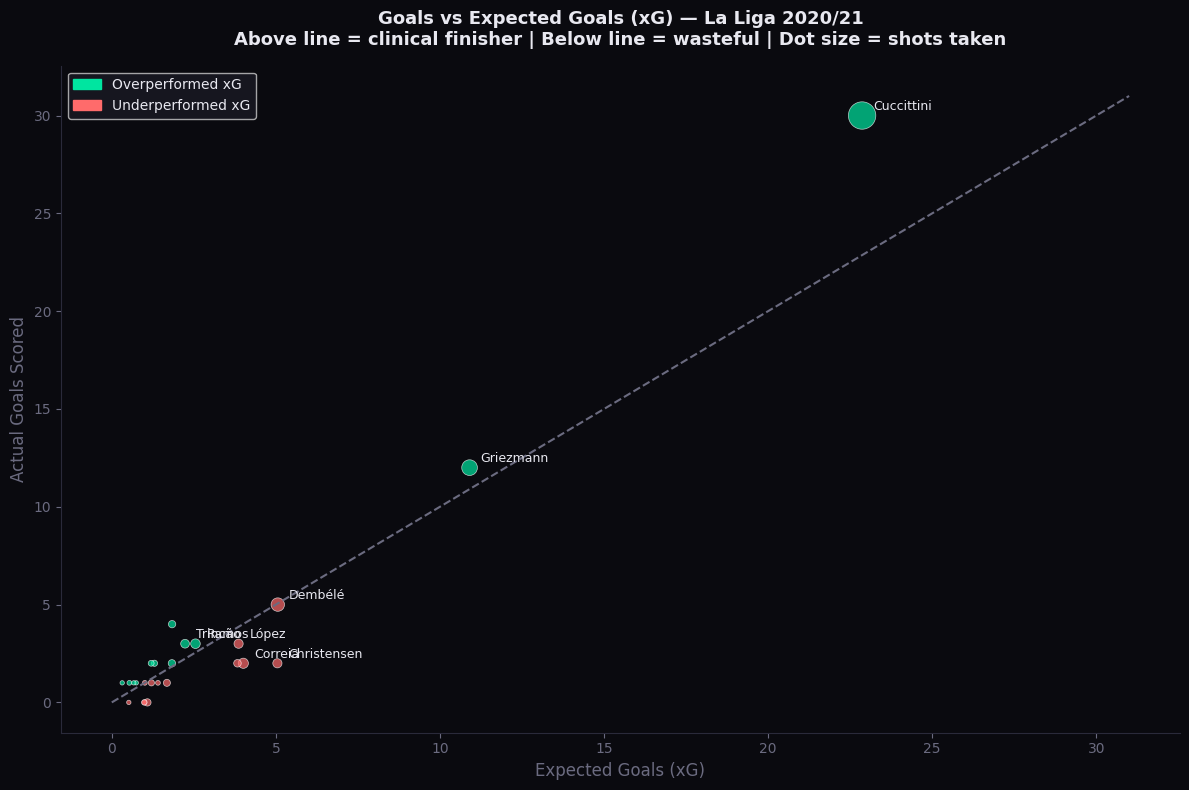

Goals vs xG chart saved


In [4]:
# ============================================
# CHART: GOALS vs xG SCATTER
# Above the line = overperformed (clinical)
# Below the line = underperformed (wasteful)
# ============================================

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#0a0a0f')

# Colour by over/underperformance
colors = ['#00e5a0' if g > 0 else '#ff6b6b'
          for g in player_stats['goals_minus_xg']]

scatter = ax.scatter(
    player_stats['xg'],
    player_stats['goals'],
    c=colors,
    s=player_stats['shots'] * 2,
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)

# Perfect performance line (goals = xG)
max_val = max(player_stats['xg'].max(),
              player_stats['goals'].max()) + 1
ax.plot([0, max_val], [0, max_val],
        '--', color='#6b6b80',
        linewidth=1.5, label='Goals = xG')

# Label top players
top_players = player_stats.nlargest(8, 'shots')
for _, row in top_players.iterrows():
    name = row['player'].split()[-1]
    ax.annotate(
        name,
        (row['xg'], row['goals']),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=9,
        color='#e8e8f0'
    )

ax.set_title('Goals vs Expected Goals (xG) — La Liga 2020/21\n'
             'Above line = clinical finisher | '
             'Below line = wasteful | '
             'Dot size = shots taken',
             color='#e8e8f0', fontsize=13,
             fontweight='bold', pad=15)
ax.set_xlabel('Expected Goals (xG)',
              color='#6b6b80', fontsize=12)
ax.set_ylabel('Actual Goals Scored',
              color='#6b6b80', fontsize=12)
ax.tick_params(colors='#6b6b80')
ax.spines['bottom'].set_color('#2a2a3a')
ax.spines['left'].set_color('#2a2a3a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
over = mpatches.Patch(color='#00e5a0',
                      label='Overperformed xG')
under = mpatches.Patch(color='#ff6b6b',
                       label='Underperformed xG')
ax.legend(handles=[over, under],
          facecolor='#1a1a24',
          labelcolor='#e8e8f0', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/goals_vs_xg.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Goals vs xG chart saved")

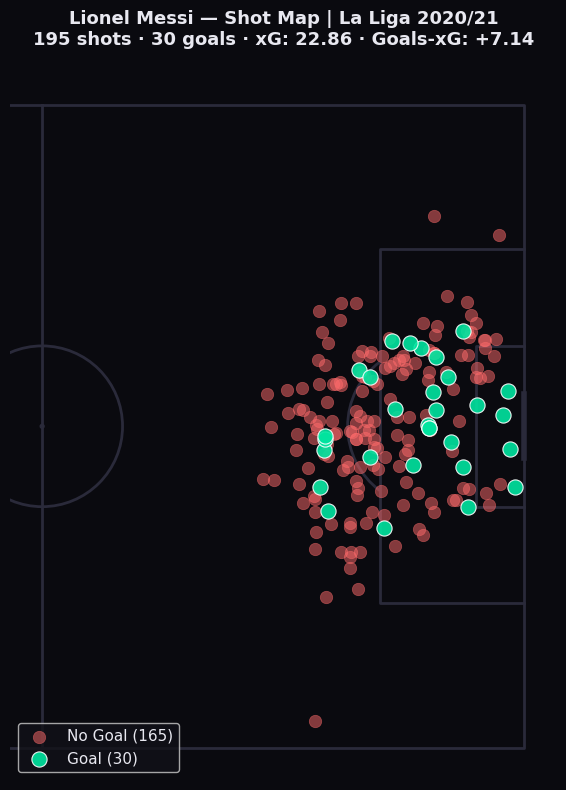

Messi shot map saved


In [5]:
# ============================================
# MESSI SHOT MAP
# Plot every Messi shot coloured by outcome
# The most iconic player in our dataset
# ============================================

messi_shots = shots[
    shots['player'].str.contains('Messi')
].copy()

pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#0a0a0f',
    line_color='#2a2a3a',
    half=True
)

fig, ax = pitch.draw(figsize=(12, 8))
fig.patch.set_facecolor('#0a0a0f')

# Non-goals
messi_miss = messi_shots[messi_shots['is_goal']==0]
messi_goal = messi_shots[messi_shots['is_goal']==1]

pitch.scatter(
    messi_miss['x'], messi_miss['y'],
    ax=ax, s=80,
    color='#ff6b6b', alpha=0.5,
    edgecolors='#ff6b6b', linewidth=0.5,
    label=f'No Goal ({len(messi_miss)})'
)

pitch.scatter(
    messi_goal['x'], messi_goal['y'],
    ax=ax, s=120,
    color='#00e5a0', alpha=0.9,
    edgecolors='white', linewidth=0.8,
    label=f'Goal ({len(messi_goal)})'
)

ax.set_title(
    f'Lionel Messi — Shot Map | La Liga 2020/21\n'
    f'{len(messi_shots)} shots · '
    f'{len(messi_goal)} goals · '
    f'xG: {messi_shots["our_xg"].sum():.2f} · '
    f'Goals-xG: +{len(messi_goal)-messi_shots["our_xg"].sum():.2f}',
    color='#e8e8f0', fontsize=13,
    fontweight='bold', pad=20
)

ax.legend(loc='lower left',
          facecolor='#111118',
          labelcolor='#e8e8f0', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/messi_shot_map.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Messi shot map saved")

In [6]:
summary = """
SUMMARY — Player xG Analysis Complete
============================================

DATASET:
- 185 unique players analysed
- 25 players with 5+ shots filtered for analysis

TOP PERFORMERS vs xG:
Player              Shots  Goals   xG   G-xG
Messi               195    30    22.86  +7.14  ← Most clinical
Griezmann            64    12    10.90  +1.10  ← Overperforming
Fati                 14     4     1.84  +2.16  ← Efficient

UNDERPERFORMERS vs xG:
Player              Shots  Goals   xG   G-xG
Braithwaite          22     2     5.05  -3.05  ← Most wasteful
Coutinho             27     2     4.01  -2.01  ← Underperforming
de Jong              15     2     3.83  -1.83  ← Below expected

KEY INSIGHTS:
1. Messi scored 7.14 goals more than expected 
   statistically exceptional finishing quality
2. Messi took 195 shots, 3x more than anyone
   else in the dataset
3. Braithwaite wasted 3 expected goals from
   good positions, poor finishing efficiency
4. Young Anssumane Fati was highly efficient
   4 goals from just 1.84 xG (+2.16)

CHARTS PRODUCED:
- Goals vs xG scatter — clinical vs wasteful
- Messi shot map — 195 shots, 30 goals
"""
print(summary)


SUMMARY — Player xG Analysis Complete

DATASET:
- 185 unique players analysed
- 25 players with 5+ shots filtered for analysis

TOP PERFORMERS vs xG:
Player              Shots  Goals   xG   G-xG
Messi               195    30    22.86  +7.14  ← Most clinical
Griezmann            64    12    10.90  +1.10  ← Overperforming
Fati                 14     4     1.84  +2.16  ← Efficient

UNDERPERFORMERS vs xG:
Player              Shots  Goals   xG   G-xG
Braithwaite          22     2     5.05  -3.05  ← Most wasteful
Coutinho             27     2     4.01  -2.01  ← Underperforming
de Jong              15     2     3.83  -1.83  ← Below expected

KEY INSIGHTS:
1. Messi scored 7.14 goals more than expected 
   statistically exceptional finishing quality
2. Messi took 195 shots, 3x more than anyone
   else in the dataset
3. Braithwaite wasted 3 expected goals from
   good positions, poor finishing efficiency
4. Young Anssumane Fati was highly efficient
   4 goals from just 1.84 xG (+2.16)

CHARTS P